# MIPAR Image Measurements

Loads per-FOV image-level measurements from MIPAR batch CSV exports using
`stamp.io.load_mipar_image` and compares key 2-D and 3-D stereological quantities
across multiple material states.

**Contents**
1. Load all material states
2. Inspect the tidy DataFrame
3. 2-D summary tables — phase fraction, particle size, interparticle spacing
4. 2-D box plots per phase (Nature journal style)
5. Derive 3-D stereological quantities — $V_V$, $S_V$, $\bar{D}$, $\lambda_{3D}$
6. 3-D summary tables
7. 3-D box plots per phase (Nature journal style)

In [1]:
%matplotlib inline
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stamp.io import load_mipar_image
from stamp.export import journal_style, save, to_csv, to_latex, NATURE

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data") if Path.cwd().name != "notebooks" else Path("data")
OUT_DIR = DATA_DIR / "GOO220_image"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "GOO220_51": DATA_DIR / "GOO220_51_BatchMeas.csv",
    "GOO220_52": DATA_DIR / "GOO220_52_BatchMeas.csv",
    "GOO220_53": DATA_DIR / "GOO220_53_BatchMeas.csv",
}

# Display labels used on plot axes — edit here to switch between time,
# strain %, or any other descriptor without touching the plot cells.
STATE_LABELS = {
    "GOO220_51": "139 kh gauge",
    "GOO220_52": "139 kh thread",
    "GOO220_53": "139 kh fracture",
}

PHASES = ["M23C6", "MX", "ZPhase", "Laves"]
PHASE_ALIASES = {}

## 1. Load all three material states

Each file contains one row per FOV.  `load_mipar_image` melts the wide-format
table to long format — one row per (FOV × phase) combination.

In [2]:
frames = []
for state, path in FILES.items():
    df = load_mipar_image(path)
    df["Phase"] = df["Phase"].replace(PHASE_ALIASES)
    df.insert(0, "State", state)
    frames.append(df)
    n_fovs = df["Image"].nunique()
    print(f"{state}: {n_fovs} FOVs × {df['Phase'].nunique()} phases → {len(df)} rows")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(df_all)} rows total")

GOO220_51: 10 FOVs × 4 phases → 40 rows
GOO220_52: 10 FOVs × 4 phases → 40 rows
GOO220_53: 10 FOVs × 4 phases → 40 rows

Combined: 120 rows total


## 2. Inspect the tidy DataFrame

In [3]:
display(df_all.head(12))
print("\nColumns:", df_all.columns.tolist())
print("\nDtypes:")
print(df_all.dtypes)
print("\nMissing values per column:")
print(df_all.isna().sum())

,State,Image,Phase,Area Fraction (%),Image Dim X (um),Image Dim Y (um),Number Density (features/um^2),Mean Intercept - Objects (Random) (um),Mean Intercept - Holes (Random) (um),Mean Inverse Intercept - Objects (Random) (1/um),Mean Inverse Intercept - Holes (Random) (1/um),Mode Intercept - Objects (Random) (um),Mode Intercept - Holes (Random) (um),Mode Inverse Intercept - Objects (Random) (1/um),Mode Inverse Intercept - Holes (Random) (1/um),ASTM Grain Size Number (Random Lines),Total Line Length (Random) (um),Total Intersections (Random)
0,GOO220_51,T3_Mode2-GOO220_51_001_processed.tif,M23C6,4.238,20.61092,13.73949,2.298863,0.125484,2.079840,15.575136,3.882040,0.070,0.25,4.5,1.5,22.6,15158.668308,11176.0
1,GOO220_51,T3_Mode2-GOO220_51_002_processed.tif,M23C6,4.268,20.61092,13.73949,2.701428,0.117092,2.024565,16.122289,4.076036,0.070,0.25,7.5,1.5,22.8,15311.425409,12149.0
2,GOO220_51,T3_Mode2-GOO220_51_003_processed.tif,M23C6,4.643,20.61092,13.73949,2.461301,0.122295,1.982648,15.904457,4.529596,0.070,0.25,7.5,1.5,22.7,14824.084422,12311.0
3,GOO220_51,T3_Mode2-GOO220_51_004_processed.tif,M23C6,4.613,20.61092,13.73949,2.870930,0.109093,1.809402,16.589914,3.900890,0.065,0.15,7.5,1.0,23.0,14856.660200,13401.0
4,GOO220_51,T3_Mode2-GOO220_51_006_processed.tif,M23C6,4.321,20.61092,13.73949,2.496614,0.117717,2.032286,15.931577,4.147453,0.070,0.25,7.5,1.5,22.8,15582.671533,12208.0
5,GOO220_51,T3_Mode2-GOO220_51_007_processed.tif,M23C6,4.391,20.61092,13.73949,1.687951,0.154166,2.328392,14.404909,4.624004,0.075,0.25,4.5,1.5,22.0,15141.531798,9472.0
6,GOO220_51,T3_Mode2-GOO220_51_008_processed.tif,M23C6,4.560,20.61092,13.73949,2.305925,0.124280,1.892542,14.875614,3.922833,0.070,0.25,7.5,1.0,22.7,14962.611110,11571.0
7,GOO220_51,T3_Mode2-GOO220_51_009_processed.tif,M23C6,4.561,20.61092,13.73949,2.517802,0.121188,2.012724,15.563770,4.080879,0.070,0.25,7.5,1.5,22.7,15152.413841,12587.0
8,GOO220_51,T3_Mode2-GOO220_51_010_processed.tif,M23C6,4.657,20.61092,13.73949,2.309456,0.125145,2.049487,15.302473,3.943293,0.090,0.25,7.5,1.5,22.6,15101.415698,12004.0
9,GOO220_51,T3_Mode2-GOO220_51_011_processed.tif,M23C6,4.579,20.61092,13.73949,2.493083,0.123707,1.998262,15.689870,3.923046,0.070,0.25,7.5,1.5,22.7,15219.321616,12032.0



Columns: ['State', 'Image', 'Phase', 'Area Fraction (%)', 'Image Dim X (um)', 'Image Dim Y (um)', 'Number Density (features/um^2)', 'Mean Intercept - Objects (Random) (um)', 'Mean Intercept - Holes (Random) (um)', 'Mean Inverse Intercept - Objects (Random) (1/um)', 'Mean Inverse Intercept - Holes (Random) (1/um)', 'Mode Intercept - Objects (Random) (um)', 'Mode Intercept - Holes (Random) (um)', 'Mode Inverse Intercept - Objects (Random) (1/um)', 'Mode Inverse Intercept - Holes (Random) (1/um)', 'ASTM Grain Size Number (Random Lines)', 'Total Line Length (Random) (um)', 'Total Intersections (Random)']

Dtypes:
State                                                   str
Image                                                   str
Phase                                                   str
Area Fraction (%)                                   float64
Image Dim X (um)                                    float64
Image Dim Y (um)                                    float64
Number Density (featur

## 3. 2-D summary tables

Mean and standard deviation across FOVs for the three key 2-D quantities —
total phase fraction, mean particle size, and 2-D interparticle spacing —
grouped by material state and phase.  Exported as CSV and LaTeX.

In [4]:
# 2-D quantities of interest
PLOT_COLS_2D = {
    "Area Fraction (%)":                       "Phase fraction (%)",
    "Mean Intercept - Objects (Random) (um)":  "Mean particle size — 2D (µm)",
    "Mean Intercept - Holes (Random) (um)":    "Interparticle spacing — 2D (µm)",
}

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]
    summary = (
        sub.groupby("State")[list(PLOT_COLS_2D.keys())]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{PLOT_COLS_2D[m]} ({stat})" for m, stat in summary.columns]
    summary = summary.reset_index()

    print(f"\n── {phase} ──")
    display(summary)

    slug = phase.replace(" ", "_")
    to_csv(summary, OUT_DIR / f"summary_2d_{slug}.csv", decimals=4)
    to_latex(
        summary,
        OUT_DIR / f"summary_2d_{slug}.tex",
        caption=f"2-D per-FOV measurement summary — {phase}.",
        label=f"tab:summary-2d-{slug.lower()}",
        decimals=4,
    )
    print(f"  Saved → {OUT_DIR / f'summary_2d_{slug}.csv'}")


── M23C6 ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,4.4831,0.1616,0.1240,0.0117,2.0210,0.1343
1,GOO220_52,3.4739,0.3689,0.0898,0.0099,1.8403,0.0840
2,GOO220_53,4.9770,0.3472,0.1315,0.0188,1.9805,0.2663


  Saved → data\GOO220_image\summary_2d_M23C6.csv

── MX ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,0.0945,0.0210,0.0419,0.0014,5.1973,0.7453
1,GOO220_52,0.1193,0.0192,0.0371,0.0012,5.5243,0.3643
2,GOO220_53,0.0943,0.0198,0.0371,0.0014,5.4682,0.7440


  Saved → data\GOO220_image\summary_2d_MX.csv

── ZPhase ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,0.3758,0.1024,0.0954,0.0093,4.2711,0.3440
1,GOO220_52,0.1185,0.0500,0.0830,0.0146,3.6560,0.8912
2,GOO220_53,0.2773,0.0632,0.0950,0.0125,4.5928,0.7638


  Saved → data\GOO220_image\summary_2d_ZPhase.csv

── Laves ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,0.6679,0.2704,0.3111,0.0460,2.7881,0.8831
1,GOO220_52,0.5757,0.2735,0.2672,0.0136,3.2092,1.3779
2,GOO220_53,0.4257,0.1433,0.2849,0.0327,3.1585,1.7245


  Saved → data\GOO220_image\summary_2d_Laves.csv


## 4. 2-D box plots per phase

For each phase: three panels comparing the three material states —
phase fraction, mean particle size (2-D), and interparticle spacing (2-D).
Rendered in Nature journal style.

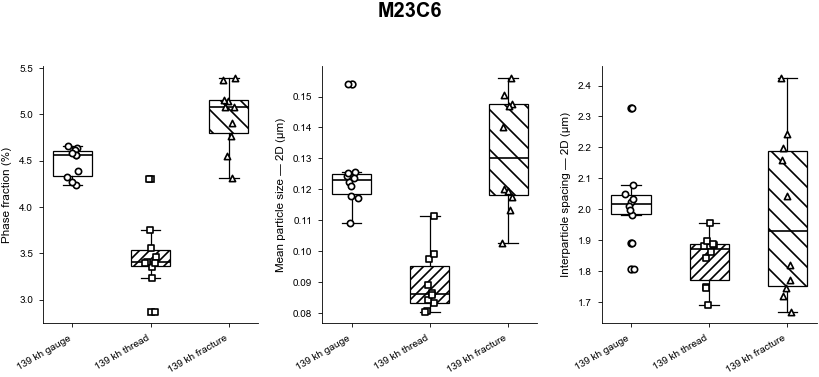

Saved M23C6 → data\GOO220_image


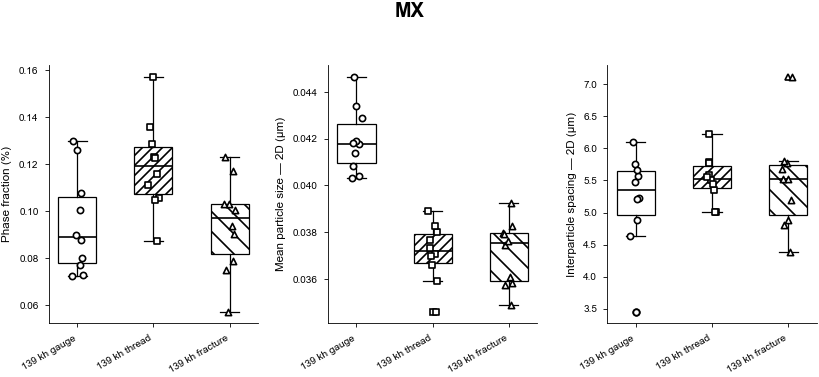

Saved MX → data\GOO220_image


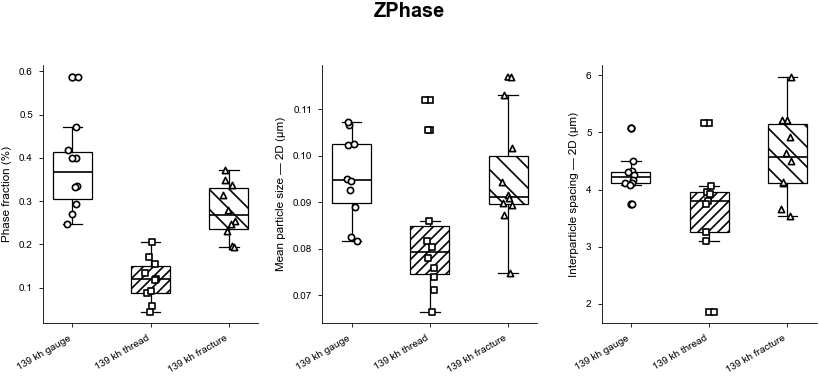

Saved ZPhase → data\GOO220_image


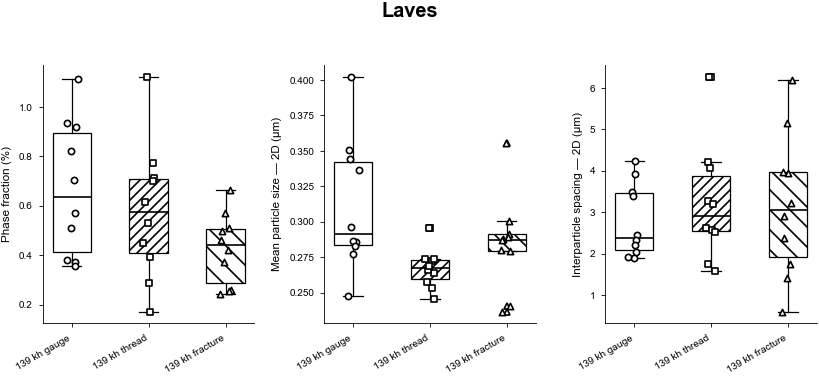

Saved Laves → data\GOO220_image


In [5]:
_BW_HATCHES = ["", "////", "\\\\", "xxxx", "....", "oooo", "////\\\\", "||", "--", "++"]
_BW_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
STATES = list(FILES.keys())

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]

    with journal_style(NATURE):
        fig, axes = plt.subplots(
            1, len(PLOT_COLS_2D),
            figsize=(180 / 25.4, 180 / 25.4 * 0.45),
            sharey=False,
        )
        rng = np.random.default_rng(42)

        for ax, (col, label) in zip(axes, PLOT_COLS_2D.items()):
            for i, state in enumerate(STATES):
                vals = sub[sub["State"] == state][col].dropna().values
                if len(vals) == 0:
                    continue
                ax.boxplot(
                    vals,
                    positions=[i + 1],
                    widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(color="black", linewidth=0.75),
                    capprops=dict(color="black", linewidth=0.75),
                    flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                   markeredgecolor="black", markersize=4),
                    manage_ticks=False,
                )
                jitter = rng.uniform(-0.08, 0.08, len(vals))
                ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                           facecolors="white", edgecolors="black", s=14, zorder=3)

            ax.set_xticks(range(1, len(STATES) + 1))
            ax.set_xticklabels(
                [STATE_LABELS.get(s, s) for s in STATES], rotation=30, ha="right"
            )
            ax.set_ylabel(label)

        fig.suptitle(f"{phase}", fontweight="bold", y=1.02)
        fig.tight_layout()
        slug = phase.replace(" ", "_")
        save(fig, OUT_DIR / f"boxplot_2d_{slug}", formats=["pdf", "png"])
        plt.show()
        print(f"Saved {phase} → {OUT_DIR}")

## 5. Derive 3-D stereological quantities

Apply four image-level stereological relations to each FOV row:

| Quantity | Formula | Reference |
|---|---|---|
| Volume fraction $V_V$ | $V_V = A_A$ | Delesse (1848) |
| Surface area density $S_V$ (µm⁻¹) | $S_V = 4V_V / \bar{L}_\alpha$ | Underwood (1970) |
| Mean caliper diameter $\bar{D}$ (µm) | $\bar{D} = \tfrac{3}{2}\bar{L}_\alpha$ | Fullman (1953) |
| 3-D mean free path $\lambda_{3D}$ (µm) | $\lambda_{3D} = 4(1-V_V)/S_V$ | Underwood (1970) |

In [6]:
from stamp.stereo import (
    mean_caliper_diameter,
    mean_free_path_3d,
    surface_area_density,
    volume_fraction,
)

L_ALPHA = "Mean Intercept - Objects (Random) (um)"

# Zero intercept means the phase was absent in that FOV — 3-D quantities are
# undefined there, so replace with NaN so they propagate cleanly downstream.
df_all[L_ALPHA] = df_all[L_ALPHA].where(df_all[L_ALPHA] > 0)

df_all["V_V"]            = volume_fraction(df_all["Area Fraction (%)"].values)
df_all["S_V (1/um)"]     = surface_area_density(
    df_all["V_V"].values, df_all[L_ALPHA].values
)
df_all["D_bar (um)"]     = mean_caliper_diameter(df_all[L_ALPHA].values)
df_all["lambda_3D (um)"] = mean_free_path_3d(
    df_all["V_V"].values, df_all["S_V (1/um)"].values
)

print("New columns:")
display(df_all[["State", "Phase", "V_V", "S_V (1/um)", "D_bar (um)", "lambda_3D (um)"]].head(12))

New columns:


,State,Phase,V_V,S_V (1/um),D_bar (um),lambda_3D (um)
0,GOO220_51,M23C6,0.04238,1.350929,0.188226,2.835441
1,GOO220_51,M23C6,0.04268,1.457999,0.175638,2.626394
2,GOO220_51,M23C6,0.04643,1.518623,0.183443,2.511670
3,GOO220_51,M23C6,0.04613,1.691401,0.163639,2.255811
4,GOO220_51,M23C6,0.04321,1.468267,0.176575,2.606583
5,GOO220_51,M23C6,0.04391,1.139291,0.231249,3.356788
6,GOO220_51,M23C6,0.04560,1.467654,0.186420,2.601159
7,GOO220_51,M23C6,0.04561,1.505430,0.181782,2.535861
8,GOO220_51,M23C6,0.04657,1.488513,0.187718,2.562100
9,GOO220_51,M23C6,0.04579,1.480595,0.185560,2.577909


## 6. 3-D summary tables

Mean and standard deviation across FOVs for the four 3-D quantities,
grouped by material state and phase.  Exported as CSV and LaTeX.

In [7]:
PLOT_COLS_3D = {
    "V_V":            "Volume fraction V_V",
    "S_V (1/um)":     "Surface area density S_V (1/um)",
    "D_bar (um)":     "Mean caliper diameter D_bar (um)",
    "lambda_3D (um)": "Mean free path lambda_3D (um)",
}

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]
    summary = (
        sub.groupby("State")[list(PLOT_COLS_3D.keys())]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{PLOT_COLS_3D[m]} ({stat})" for m, stat in summary.columns]
    summary = summary.reset_index()

    print()
    print(f"-- {phase} --")
    display(summary)

    slug = phase.replace(" ", "_")
    to_csv(summary, OUT_DIR / f"summary_3d_{slug}.csv", decimals=4)
    to_latex(
        summary,
        OUT_DIR / f"summary_3d_{slug}.tex",
        caption="3-D stereological quantity summary -- " + phase + ".",
        label="tab:summary-3d-" + slug.lower(),
        decimals=4,
    )
    print("  Saved ->", OUT_DIR / ("summary_3d_" + slug + ".csv"))


-- M23C6 --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_51,0.0448,0.0016,1.4569,0.1395,0.1860,0.0176,2.6470,0.2866
1,GOO220_52,0.0347,0.0037,1.5565,0.1643,0.1346,0.0148,2.5077,0.2858
2,GOO220_53,0.0498,0.0035,1.5432,0.2429,0.1972,0.0282,2.5242,0.4390


  Saved -> data\GOO220_image\summary_3d_M23C6.csv

-- MX --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_51,0.0009,0.0002,0.0903,0.0207,0.0629,0.0021,46.1895,9.5141
1,GOO220_52,0.0012,0.0002,0.1290,0.0239,0.0557,0.0019,31.9082,5.7557
2,GOO220_53,0.0009,0.0002,0.1021,0.0233,0.0556,0.0021,41.3550,11.1568


  Saved -> data\GOO220_image\summary_3d_MX.csv

-- ZPhase --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_51,0.0038,0.0010,0.1562,0.0325,0.1430,0.0139,26.4334,5.0069
1,GOO220_52,0.0012,0.0005,0.0554,0.0168,0.1246,0.0220,80.6517,33.0951
2,GOO220_53,0.0028,0.0006,0.1160,0.0163,0.1425,0.0188,35.0451,5.1244


  Saved -> data\GOO220_image\summary_3d_ZPhase.csv

-- Laves --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_51,0.0067,0.0027,0.0836,0.0248,0.4666,0.0690,51.7684,16.3866
1,GOO220_52,0.0058,0.0027,0.0859,0.0383,0.4008,0.0203,60.1969,39.9779
2,GOO220_53,0.0043,0.0014,0.0597,0.0184,0.4274,0.0491,73.7922,26.1658


  Saved -> data\GOO220_image\summary_3d_Laves.csv


## 7. 3-D box plots per phase

For each phase: four panels comparing the three material states.
Rendered in Nature journal style.

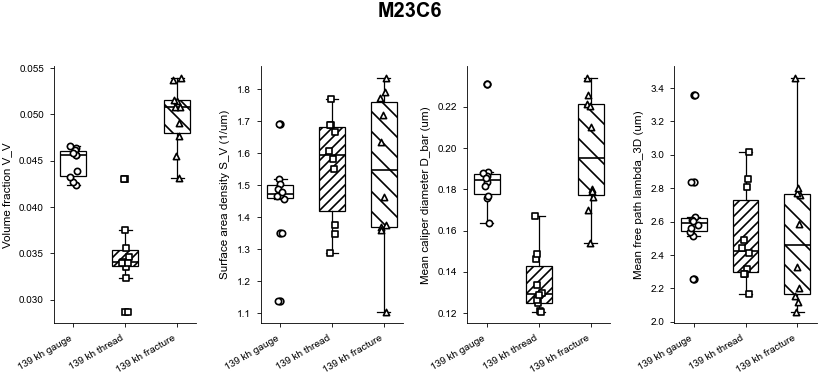

Saved M23C6 -> data\GOO220_image


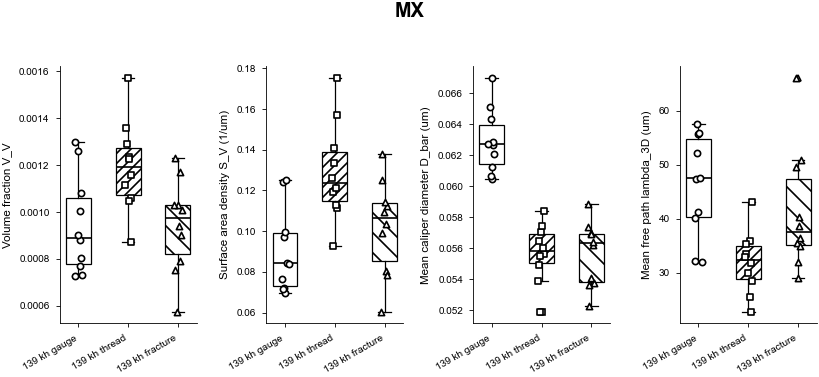

Saved MX -> data\GOO220_image


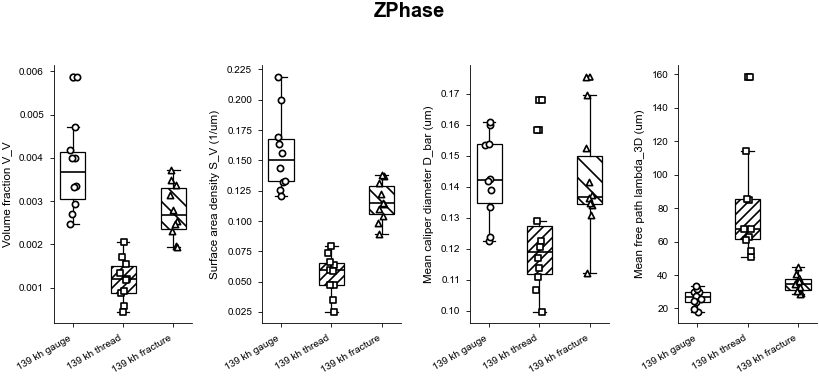

Saved ZPhase -> data\GOO220_image


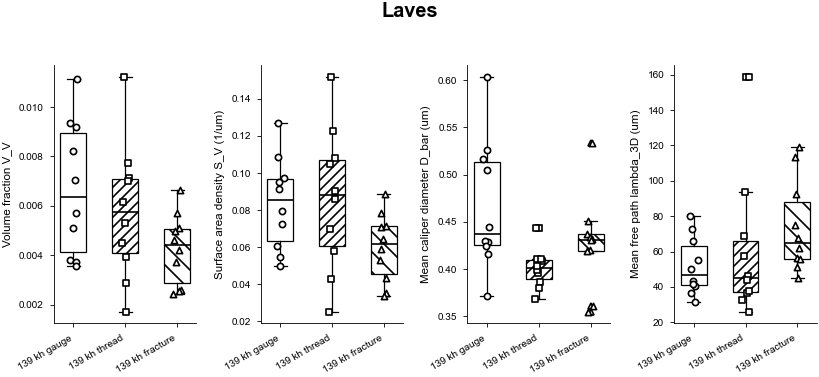

Saved Laves -> data\GOO220_image


In [8]:
for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]

    with journal_style(NATURE):
        fig, axes = plt.subplots(
            1, len(PLOT_COLS_3D),
            figsize=(180 / 25.4, 180 / 25.4 * 0.45),
            sharey=False,
        )
        rng = np.random.default_rng(42)

        for ax, (col, label) in zip(axes, PLOT_COLS_3D.items()):
            for i, state in enumerate(STATES):
                vals = sub[sub["State"] == state][col].dropna().values
                if len(vals) == 0:
                    continue
                ax.boxplot(
                    vals,
                    positions=[i + 1],
                    widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(color="black", linewidth=0.75),
                    capprops=dict(color="black", linewidth=0.75),
                    flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                   markeredgecolor="black", markersize=4),
                    manage_ticks=False,
                )
                jitter = rng.uniform(-0.08, 0.08, len(vals))
                ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                           facecolors="white", edgecolors="black", s=14, zorder=3)

            ax.set_xticks(range(1, len(STATES) + 1))
            ax.set_xticklabels(
                [STATE_LABELS.get(s, s) for s in STATES], rotation=30, ha="right"
            )
            ax.set_ylabel(label)

        fig.suptitle(f"{phase}", fontweight="bold", y=1.02)
        fig.tight_layout()
        slug = phase.replace(" ", "_")
        save(fig, OUT_DIR / f"boxplot_3d_{slug}", formats=["pdf", "png"])
        plt.show()
        print(f"Saved {phase} -> {OUT_DIR}")

## Next steps

A `stamp.pipeline.run_mipar_image()` orchestrator that wraps loading,
3-D quantity derivation, and multi-state comparison plots into a single
call will be added in a future update.